Filter out known actives that were used to build the QSAR model, we already know the affinity of those compounds and do not need to further study them.

In [1]:
import pandas as pd

known_actives = pd.read_csv("data/DATASET_ic50_cleaned_compounds.csv")
id_list = known_actives["molecule_chembl_id"].tolist()

In [ ]:
# cli commands for quick manipulation of huge csv file
!zcat predictions/predictions_minimal.csv.gz | head -n 1 > predictions/chembl_screen_sorted.csv
!zcat predictions/predictions_minimal.csv.gz | tail -n +2 | sort -t',' -k5,5r >> predictions/chembl_screen_sorted.csv
!cat predictions/chembl_screen_sorted.csv | head -n 5001 > predictions/chembl_screen_top_5k

In [18]:
top_5k_chembl_screen = pd.read_csv("predictions/chembl_screen_top_5k.csv")

In [19]:
len(top_5k_chembl_screen)

5000

In [20]:
chembl_screen_filtered = top_5k_chembl_screen[~top_5k_chembl_screen["compound_name"].isin(id_list)]

In [21]:
len(chembl_screen_filtered)

4877

In [22]:
chembl_screen_filtered.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
0,CHEMBL5428596,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,True,9.288634,True,0.640722,High
3,CHEMBL5315142,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High
4,CHEMBL5315168,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High
7,CHEMBL5569798,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,True,9.103165,True,0.615259,High
9,CHEMBL5286333,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,True,9.051933,True,0.669467,High


In [23]:
chembl_screen_filtered.tail()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
4995,CHEMBL5838793,CCOc1cccc(CN2[C@H]3CCN(c4ccc(C(=O)OC)cc4)C(=O)...,CCOc1cccc(CN2[C@H]3CCN(c4ccc(C(=O)OC)cc4)C(=O)...,True,6.813692,True,0.491088,High
4996,CHEMBL5902780,CCOc1cccc(CN2[C@@H]3CCN(c4ccc(C(=O)OC)cc4)C(=O...,CCOc1cccc(CN2[C@@H]3CCN(c4ccc(C(=O)OC)cc4)C(=O...,True,6.813692,True,0.491088,High
4997,CHEMBL236297,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(=O)c(c5o...,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(=O)c(c5o...,True,6.813672,True,0.456747,High
4998,CHEMBL4647002,CCCN1CCN(c2cc(O)c3nc4c5c6c7c(C)c(O)c5c(=O)c(c-...,CCCN1CCN(c2cc(O)c3nc4c5c6c7c(C)c(O)c5c(=O)c(c-...,True,6.813672,True,0.456673,High
4999,CHEMBL4798248,CO[C@H]1/C=C\O[C@@]2(C)Oc3c(C)c(O)c4c(=O)c(c5o...,CO[C@H]1/C=C\O[C@@]2(C)Oc3c(C)c(O)c4c(=O)c(c5o...,True,6.813672,True,0.456747,High


In [24]:
chembl_screen_filtered = chembl_screen_filtered[(chembl_screen_filtered["valid"]) & (chembl_screen_filtered["inside_ad"])]

In [ ]:
len(chembl_screen_filtered)

4877

In [38]:
# This creates a DataFrame containing only the rows that are duplicates
duplicates = chembl_screen_filtered[chembl_screen_filtered.duplicated(subset=["standardized_smiles"], keep=False)]

# Sort by SMILES to see the identical pairs next to each other
duplicates_sorted = duplicates.sort_values("standardized_smiles")

In [ ]:
duplicates_sorted.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
2497,CHEMBL4646526,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,True,6.951196,True,0.429226,High
2498,CHEMBL4650602,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,True,6.951196,True,0.429226,High


In [ ]:
#CHEMBL4646526 has salt attached, resulting in same standardized_smiles so will remove it
duplicates_sorted["input_smiles"].values

array(['CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(COc5ncc(-c6ccnc7[nH]ncc67)cc5C)(CC3)CC4)c3ccc(S(=O)(=O)O)cc3C2(C)C)C(C)(C)c2cc(S(=O)(=O)O)ccc21.O=C([O-])C(F)(F)F',
       'CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(COc5ncc(-c6ccnc7[nH]ncc67)cc5C)(CC3)CC4)c3ccc(S(=O)(=O)O)cc3C2(C)C)C(C)(C)c2cc(S(=O)(=O)O)ccc21'],
      dtype=object)

In [45]:
chembl_screen_filtered = chembl_screen_filtered[~(chembl_screen_filtered["compound_name"] == "CHEMBL4646526")]

In [46]:
len(chembl_screen_filtered)

4876

In [54]:
import datamol as dm
import tqdm

chembl_screen_filtered["clean_mols"] = dm.parallelized(dm.to_mol, chembl_screen_filtered["standardized_smiles"].values, n_jobs=-1)

In [57]:
# Check which values are NaN
is_missing = chembl_screen_filtered["clean_mols"].isna()

# Count how many failed standardization
print(f"Number of failed molecules: {is_missing.sum()}")

Number of failed molecules: 0


In [58]:
from rdkit.Chem import rdMolDescriptors, Crippen, Lipinski, QED

def get_extended_descriptors(mol):
    """Function to calculate 8 descriptors for a single molecule."""
    if mol is None:
        return {col: None for col in ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]}
    
    return {
        "MW": rdMolDescriptors.CalcExactMolWt(mol),
        "ClogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "QED": QED.qed(mol),
        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumAromaticRings": Lipinski.NumAromaticRings(mol)
    }

# Run parallel processing on the column containing RDKit Mol objects
results = dm.parallelized(get_extended_descriptors, chembl_screen_filtered["clean_mols"].values, n_jobs=-1)

In [62]:
desc_df = pd.DataFrame(results)
desc_df.isna().values.any()

False

In [63]:
df1 = chembl_screen_filtered.reset_index(drop=True)
df2 = desc_df.reset_index(drop=True)

In [64]:
# Merge back to the main dataframe
df = pd.concat([df1, df2], axis=1)

In [65]:
df["HBD_HBA"] = df["HBD"] + df["HBA"]
descriptors = ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]
print("Missing values per column:")
print(df[descriptors].isna().sum())

Missing values per column:
MW                  0
ClogP               0
TPSA                0
HBD                 0
HBA                 0
QED                 0
FractionCsp3        0
NumAromaticRings    0
dtype: int64


In [66]:
df.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability,clean_mols,MW,ClogP,TPSA,HBD,HBA,QED,FractionCsp3,NumAromaticRings,HBD_HBA
0,CHEMBL5428596,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,True,9.288634,True,0.640722,High,<rdkit.Chem.rdchem.Mol object at 0x123f01c60>,803.397060,7.06910,124.97,3,10,0.151540,0.565217,4,13
1,CHEMBL5315142,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High,<rdkit.Chem.rdchem.Mol object at 0x123f01300>,600.246059,4.70590,86.64,2,8,0.319044,0.424242,4,10
2,CHEMBL5315168,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High,<rdkit.Chem.rdchem.Mol object at 0x123f5c630>,600.246059,4.70590,86.64,2,8,0.319044,0.424242,4,10
3,CHEMBL5569798,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,True,9.103165,True,0.615259,High,<rdkit.Chem.rdchem.Mol object at 0x1240a71a0>,598.230409,5.50528,98.40,1,8,0.300797,0.393939,4,9
4,CHEMBL5286333,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,True,9.051933,True,0.669467,High,<rdkit.Chem.rdchem.Mol object at 0x123f5f240>,602.258612,4.70590,86.64,2,8,0.318151,0.424242,4,10


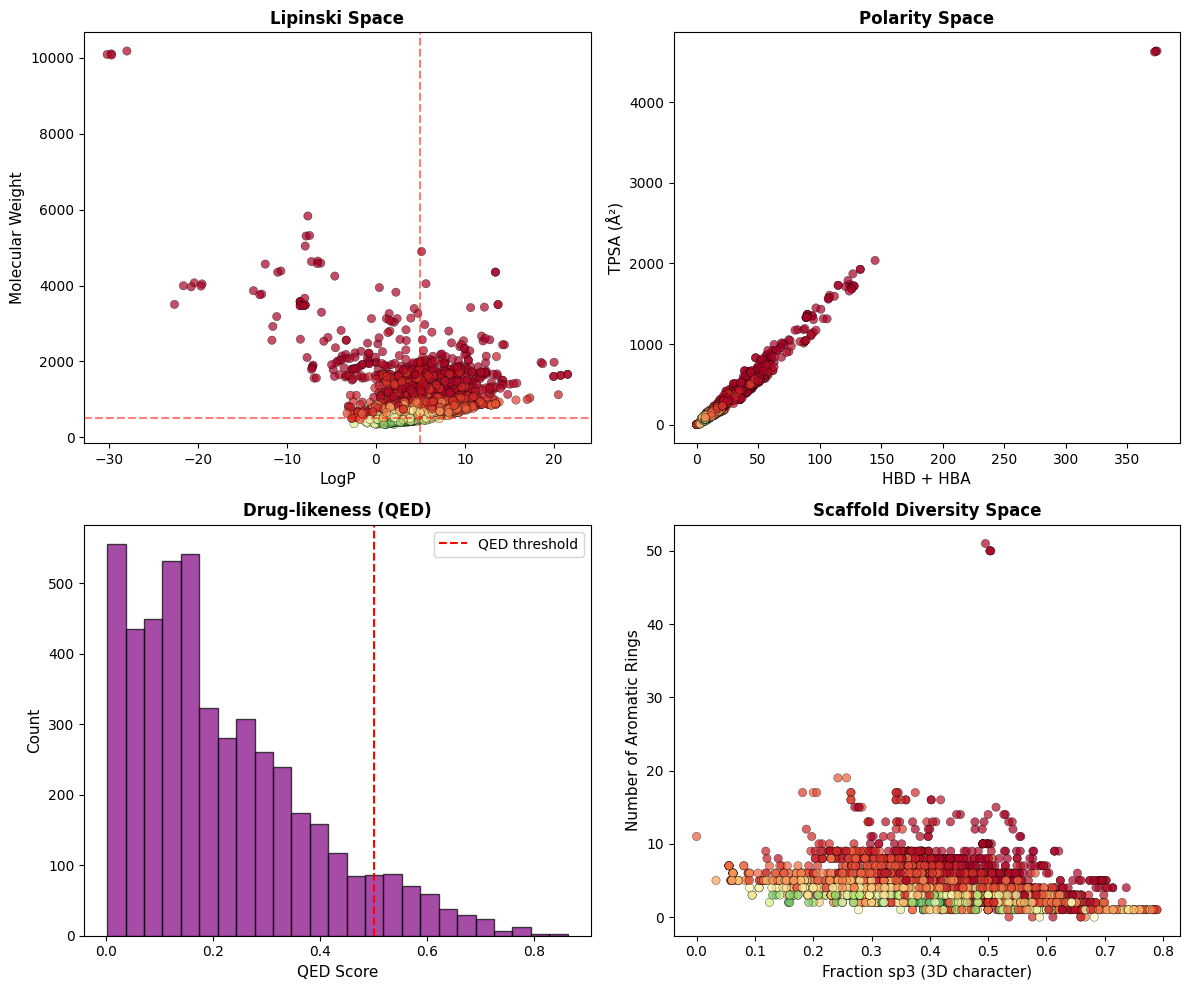

In [67]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================================
# CHEMICAL SPACE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MW vs LogP (Lipinski space)
ax1 = axes[0, 0]
scatter = ax1.scatter(df['ClogP'], df['MW'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)
ax1.axhline(y=500, color='red', linestyle='--', alpha=0.5, label='Lipinski MW')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Lipinski LogP')
ax1.set_xlabel('LogP', fontsize=11)
ax1.set_ylabel('Molecular Weight', fontsize=11)
ax1.set_title('Lipinski Space', fontsize=12, fontweight='bold')

# TPSA vs HBD+HBA
ax2 = axes[0, 1]
df['HB_total'] = df['HBD'] + df['HBA']
scatter2 = ax2.scatter(df['HB_total'], df['TPSA'],
                        cmap='RdYlGn',
                        c=df['QED'],
                       alpha=0.7, edgecolor='k', linewidth=0.3)
ax2.set_xlabel('HBD + HBA', fontsize=11)
ax2.set_ylabel('TPSA (Å²)', fontsize=11)
ax2.set_title('Polarity Space', fontsize=12, fontweight='bold')

# QED distribution
ax3 = axes[1, 0]
ax3.hist(df['QED'], bins=25, edgecolor='black', alpha=0.7, color='purple')
ax3.axvline(x=0.5, color='red', linestyle='--', label='QED threshold')
ax3.set_xlabel('QED Score', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Drug-likeness (QED)', fontsize=12, fontweight='bold')
ax3.legend()

ax4 = axes[1, 1]  # e.g., bottom-right panel

scatter = ax4.scatter(df['FractionCsp3'],
                      df['NumAromaticRings'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)

ax4.set_xlabel('Fraction sp3 (3D character)', fontsize=11)
ax4.set_ylabel('Number of Aromatic Rings', fontsize=11)
ax4.set_title('Scaffold Diversity Space', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/candidates_chemical_space.png', dpi=300, bbox_inches='tight')
plt.show()